<br></br>
<center><font size="+3">Project </font></center>
<br></br>
<center><font size="+1">Roberto Casaluce</font></center>


---

In [5]:
!pip install lime

!pip install memory_profiler

In [6]:
import random
from numpy.random import seed
seed(3)
import numpy as np
np.random.default_rng
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold,GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.svm import SVC
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.io import arff
import pandas as pd
from sklearn.decomposition import PCA
import time
import lime
import shap
%load_ext memory_profiler

<br></br>
<left><font size="+3">DDoS Dataset</font></left>
<br></br>



## Aim and Information about the Dataset

The aim would be to train a classifier able to discrimanate between a normal type of network behaviour from malicious <a href = "https://www.cloudflare.com/learning/ddos/what-is-a-ddos-attack/" target = "_self">__DDoS attacks__</a>. In the dataset are included four types of attacks flows   <a href = "https://en.wikipedia.org/wiki/UDP_flood_attack" target = "_self">'UDP-Flood'</a>,  <a href = "https://en.wikipedia.org/wiki/Smurf_attack" target = "_self">'Smurf'</a>,  'SIDDOS', <a href = "https://www.cloudflare.com/learning/ddos/http-flood-ddos-attack/" target = "_self"> 'HTTP-FLOOD'</a> but I will train a binary classification able to classify between normal and malicious traffic network and to do so, I will merge the four types of malicious attacks in one. At the end of the training phase, I have added a section to explain the outcome of the classification model using two Explainable AI models, SHAP that can give a Local and Global explaination and LIME which is only for Local explaination.

### Steps:
<ul>
    <li> <b>1. Load the DDoS dataset</b></li>
    <ul>
       <li>1.1 Fix loading problems</li>
    </ul>
    <br>
<li><b> 2. EDA</b></li>
     <ul>
         <li>2.1 Check for missing values and duplicates</li>
         <li>2.2 Create dummies columns for FLAGS feature</li>
         <li>2.2 Check for highly correlated features</li>
          <li>2.2.1 Drop highly correlated features</li>
           <li>2.3 Data Visualization</li>
           <li>2.3.1 Scale the features to plot them</li>
           <li>2.3.2 Pairwise Plots <b>(IT CANNOT BE RUN HERE)</b></li>
           <li>2.3.3 Plot Outliners</li>
           <li>2.3.4 PCA Scatter Plot <b>(IT CANNOT BE RUN HERE)</b></li>
         <li>2.4 Check for highly correlated features</li>
          <li>2.2.1 Drop highly correlated features</li>
        </ul>
    <br>
<li><b> 3. Preparing the dataset for the training</b></li>
    <ul>
       <li>3.1 Check if the data is unbalanced</li>
       <li>3.2 Merge Malicious Flows in one category</li>
       <li>3.3 Split the dataset in two sets</li>
       <li>3.4 SMOTE technique to balance the train dataset</li>
       <li>3.5 Split the train dataset for validation use</li>
      </ul>
    <br>
<li><b> 4. Test Harness with Cross Validation</b></li>
    <ul>
       <li>4.1 Pipelines of learning algorithms</li>
       <li>4.2 Spot-check the best model using Box and Whiskers Plots</li>
       </ul>
    <br>
<li><b> 5. Training phase</b></li>
    <ul>
       <li>5.1 Train the best learning algorithm</li>
        <li>5.1.1 Traing without tuning the parameters</li>     
        <li>5.2 Tune the hyperparameters of the learning algorithm</li>
        <li>5.2.1 Random Search CV to find the best hyperparameters</li>
        <li>5.3 Traing with the tuned the parameters</li>
    </ul>
    <br>
    <li><b> 6. XAI</b></li>
    <ul>
        <li>6.1 SHAP</li>
        <li>6.1.1 SHAP Global Explaination</li>
        <li>6.1.2 SHAP Local Explaination</li>
        <li>6.2 LIME</li>
        <li>6.2.1 LIME Local Explaination</li>
    </ul>



# 1. Load the DDoS dataset

In [8]:
%%memit
https://www.kaggle.com/datasets/jacobvs/ddos-attack-network-logs?select=final-dataset.arff

data, meta = arff.loadarff('/kaggle/input/ddos-attack-network-logs/final-dataset.arff')
df = pd.DataFrame(data)

peak memory: 3589.56 MiB, increment: 3032.17 MiB


__I will use for this work only a sample bacause it requires a lot computational power to train a calssificatioin on the whole dataset.__

In [9]:
df_target = df[df.columns[-1]]
df_X = df.iloc[:,:-1]

In [11]:
_, X_feature, _, y_target = train_test_split(df_X, df_target,
                                                    test_size=0.40, random_state=2, stratify= df_target)

In [12]:
df = pd.concat([X_feature, y_target], axis=1)

In [13]:
df.head(2)

,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,PKT_CLASS
1896118,24.14,14.0,154688.0,24.0,23.0,b'ack',55.0,b'-------',15.0,4821.0,...,328.432001,18063.800000,55.0,0.008446,0.000000,15.777890,15.807900,1.030038,50.059974,b'Normal'
1959586,24.70,7.0,8732.0,23.0,21.0,b'tcp',64.0,b'-------',0.0,-1.0,...,23.255775,1488.369621,64.0,0.000128,0.030015,9.108642,9.138657,0.108642,9.138657,b'Normal'


In [14]:
print(f'Number of rows {df.shape[0]} and number of columns {df.shape[1]}')

Number of rows 864268 and number of columns 28


## 1.1 Fix loading problems

We can see that some of values in the cells are not correctly loaded into the dataframe. In fact, for instance, the feature <font color=red>FLAGS</font> still left encoded in bytes as it can be seen by letter 'b' starting the sequence of symbols. There are other problems related to the loading phase because some of the features that clearly should be represented by integers are now floating numbers, such as for the feature <font color=red>FROM_NODE</font>. Before wworking on the  

### I convert each rows that are in bytes into strings

In [15]:
#decode bytes sequences in strings
df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)

In [16]:
df.head(2)

,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,PKT_CLASS
1896118,24.14,14.0,154688.0,24.0,23.0,ack,55.0,-------,15.0,4821.0,...,328.432001,18063.800000,55.0,0.008446,0.000000,15.777890,15.807900,1.030038,50.059974,Normal
1959586,24.70,7.0,8732.0,23.0,21.0,tcp,64.0,-------,0.0,-1.0,...,23.255775,1488.369621,64.0,0.000128,0.030015,9.108642,9.138657,0.108642,9.138657,Normal


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864268 entries, 1896118 to 682597
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   SRC_ADD           864268 non-null  float64
 1   DES_ADD           864268 non-null  float64
 2   PKT_ID            864268 non-null  float64
 3   FROM_NODE         864268 non-null  float64
 4   TO_NODE           864268 non-null  float64
 5   PKT_TYPE          864268 non-null  object 
 6   PKT_SIZE          864268 non-null  float64
 7   FLAGS             864268 non-null  object 
 8   FID               864268 non-null  float64
 9   SEQ_NUMBER        864268 non-null  float64
 10  NUMBER_OF_PKT     864268 non-null  float64
 11  NUMBER_OF_BYTE    864268 non-null  float64
 12  NODE_NAME_FROM    864268 non-null  object 
 13  NODE_NAME_TO      864268 non-null  object 
 14  PKT_IN            864268 non-null  float64
 15  PKT_OUT           864268 non-null  float64
 16  PKT_R             8

### Fix some columns loaded with the wrong data type.
Some columns after loading the dataset have been loaded with a wrong data type, in fact, instead of integers in those columns now they are float numbers. With snipped code below, I convert back those columns to the right data type format.

In [18]:
df['FROM_NODE'] = df['FROM_NODE'].apply(np.int64)
df['TO_NODE'] = df['TO_NODE'].apply(np.int64)
df['PKT_SIZE'] = df['PKT_SIZE'].apply(np.int64)
df['FID'] = df['FID'].apply(np.int64)
df['SEQ_NUMBER'] = df['SEQ_NUMBER'].apply(np.int64)
df['NUMBER_OF_PKT'] = df['NUMBER_OF_PKT'].apply(np.int64)
df['NUMBER_OF_BYTE'] = df['NUMBER_OF_BYTE'].apply(np.int64)
df['PKT_ID'] = df['PKT_ID'].apply(np.int64)

The features below have been loaded as a `floats` columns, instead of being loaded as object columns, I convert them as `integers` to drop the .0, which corrispondes to decimal numbers the float format adds on the values in the cells, before transforming back to `object` those columns.   

In [19]:
df['PKT_ID']= df['PKT_ID'].astype(object)
df['FID']= df['FID'].astype(object)
df['FROM_NODE']= df['FROM_NODE'].astype(object)
df['TO_NODE']= df['TO_NODE'].astype(object)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864268 entries, 1896118 to 682597
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   SRC_ADD           864268 non-null  float64
 1   DES_ADD           864268 non-null  float64
 2   PKT_ID            864268 non-null  object 
 3   FROM_NODE         864268 non-null  object 
 4   TO_NODE           864268 non-null  object 
 5   PKT_TYPE          864268 non-null  object 
 6   PKT_SIZE          864268 non-null  int64  
 7   FLAGS             864268 non-null  object 
 8   FID               864268 non-null  object 
 9   SEQ_NUMBER        864268 non-null  int64  
 10  NUMBER_OF_PKT     864268 non-null  int64  
 11  NUMBER_OF_BYTE    864268 non-null  int64  
 12  NODE_NAME_FROM    864268 non-null  object 
 13  NODE_NAME_TO      864268 non-null  object 
 14  PKT_IN            864268 non-null  float64
 15  PKT_OUT           864268 non-null  float64
 16  PKT_R             8

# 2. EDA

## 2.1 check for missing values and duplicates

__Missing values__


To check for missing values, I use two functions - <font color=blue>isnull()</font> and <font color=blue>dropna()</font> to make sure that in the dataset are not left any missing values.  

In [21]:
#if at least one of the cell in any rows is empty - misssing value - the function will return True and False otherwise.
df.isnull().values.any()

False

In [22]:
df.shape

(864268, 28)

In [23]:
missing = df.isna().sum()
missing

,0
SRC_ADD,0
DES_ADD,0
PKT_ID,0
FROM_NODE,0
TO_NODE,0
PKT_TYPE,0
PKT_SIZE,0
FLAGS,0
FID,0
SEQ_NUMBER,0


To double-check that the function <font color=blue>isnull()</font> is correct, we use also the function dropna() that will delete rows whenever a value is missing in one the features.

In [24]:
new_df = df.dropna()
new_df.shape

(864268, 28)

Also function <font color=blue>dropna()</font> conferms that there are no missing values in any of the cells of the rows of the dataset since the number of rows is constant, i.e. 2160668.

__Check for duplicates__

In [25]:
dups = df.duplicated()
print(f'Are there duplicate rows? = {dups.any()}')

Are there duplicate rows? = False


## Split Features From Target variable

In [26]:
df_target = df[df.columns[-1]]
df_X = df.iloc[:,:-1]

In [27]:
df_X.head(2)

,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_DELAY_NODE,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED
1896118,24.14,14.0,154688,24,23,ack,55,-------,15,4821,...,0.0,328.432001,18063.800000,55.0,0.008446,0.000000,15.777890,15.807900,1.030038,50.059974
1959586,24.70,7.0,8732,23,21,tcp,64,-------,0,-1,...,0.0,23.255775,1488.369621,64.0,0.000128,0.030015,9.108642,9.138657,0.108642,9.138657


## 2.2 Create dummies columns for FLAGS feature


to substituite the column FLAGS which only two flags '-------' and '---A---'
I have first replaced with 0 and 1 respectively the two flags and only after I have created two columns from them which namend FLAGS_0 and FLAGS_1.

In [28]:
df_X.FLAGS.value_counts()

,count
FLAGS,
-------,863939
---A---,329


In [29]:
df_X['FLAGS'] = df_X.FLAGS.replace(to_replace=['-------', '---A---'], value=[0, 1])

In [30]:
#merge the original dataset with the new columns created from the FLAGS column
df_X = pd.concat([df_X,pd.get_dummies(df_X['FLAGS'], prefix='FLAGS')],axis=1)

#drop the orginal column FLAGS
df_X.drop(['FLAGS'],axis=1, inplace=True)

Below the newly created dummy features for the column <font color=red>FLAGS</font>.

In [31]:
df_X.iloc[:,-2:].head(2)

,FLAGS_0,FLAGS_1
1896118,True,False
1959586,True,False


## 2.3 Data Visualization

### 2.3.1 Scale the features to plot them

I select only the numeric features to calculate the correlation without including the first two columns <font color=red>SRC_ADD</font> and <font color=red>DES_ADD</font> since they correspond only to the source and destination of the packages sent. Nevertheless, for training the model, I will drop all the columns that are not numeric one and the two dummy columns for the Flags.   

In [32]:
df_for_scaling = df_X[df_X.columns[2:]].select_dtypes(include=['float64','int64'])

In [33]:
%%memit
scaler = StandardScaler()
scaled_features =scaler.fit_transform(df_for_scaling.values)

df_X_scaled = pd.DataFrame(scaled_features, index=df_for_scaling.index, columns=df_for_scaling.columns)
df_X_scaled.head(2)

peak memory: 3071.30 MiB, increment: 114.54 MiB


__I concatenate the features scaled with the new dummy features FLAGS and the target variable.__

In [34]:
df_scaled = pd.concat([df_X_scaled, df_X.iloc[:,-2:], df_target], axis=1)

In [35]:
df_scaled.head(2)

,PKT_SIZE,SEQ_NUMBER,NUMBER_OF_PKT,NUMBER_OF_BYTE,PKT_IN,PKT_OUT,PKT_R,PKT_DELAY_NODE,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,FLAGS_0,FLAGS_1,PKT_CLASS
1896118,-0.306547,-0.099316,0.616347,-0.996287,-0.866914,-0.866966,-0.866978,-0.116719,-0.087485,-0.786421,-0.306546,-0.996291,-0.294255,-0.866361,-0.866439,-0.455753,-0.037305,True,False,Normal
1959586,-0.303760,-0.134257,-3.112518,-1.078997,-1.238273,-1.238322,-1.238328,-0.116719,-1.474001,-0.827965,-0.303759,-1.078999,1.221620,-1.238291,-1.238335,-0.557244,-2.503612,True,False,Normal


### 2.3.2 Pairwise Plot

In [36]:
#%%memit
#Plot pairwise relationships in a dataset.
#sns.pairplot(df_scaled, hue='PKT_CLASS', diag_kws={'bw': 0.9}, plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'})
#plt.show()

In the main diagonal, the pairplot function returns the <u>univariate histograms</u> for each features, in other words, the distribution of a single variable. While the plots of the diagonal, on the upper and lower triangles, show the relationship, if at all, between two variables. Some features show very high positive correlation PKT_OUT,PKT_IN ,PKT_AVG_SIZE ,PKT_R ,PKT_SIZE ,PKT_RESEVED_TIME ,PKT_SEND_TIME. I change the transformation of the data which should allow me to visualize better those features since the HTTP-FLOOD attacks cover all the other types of network flows.

__Log Transformation__

In [37]:
#the df is the unscaled version of the dataset.
df_log = df_X[["PKT_OUT", "PKT_R", "PKT_IN", "PKT_AVG_SIZE","PKT_SEND_TIME","PKT_RESEVED_TIME", "PKT_SIZE"]]
df_log.head(2)

,PKT_OUT,PKT_R,PKT_IN,PKT_AVG_SIZE,PKT_SEND_TIME,PKT_RESEVED_TIME,PKT_SIZE
1896118,15.777890,15.787893,15.777890,55.0,15.777890,15.807900,55
1959586,9.118647,9.128652,9.118647,64.0,9.108642,9.138657,64


In [38]:
df_log['PKT_OUT_log'] = np.log10(df_log['PKT_OUT'])
df_log['PKT_IN_log'] = np.log10(df_log['PKT_IN'])
df_log['PKT_AVG_SIZE_log'] = np.log10(df_log['PKT_AVG_SIZE'])
df_log['PKT_R_log'] = np.log10(df_log['PKT_R'])
df_log['PKT_SIZE_log'] = np.log10(df_log['PKT_SIZE'])
df_log['PKT_RESEVED_TIME_log'] = np.log10(df_log['PKT_RESEVED_TIME'])
df_log['PKT_SEND_TIME_log'] = np.log10(df_log['PKT_SEND_TIME'])

# Drop the non-transformed columns
df_log = df_log.drop(columns = ['PKT_OUT', 'PKT_IN', 'PKT_AVG_SIZE', 'PKT_IN','PKT_SIZE','PKT_R','PKT_RESEVED_TIME','PKT_SEND_TIME'])
df_log = pd.concat([df_log, df_target], axis=1)
df_log.head(2)

,PKT_OUT_log,PKT_IN_log,PKT_AVG_SIZE_log,PKT_R_log,PKT_SIZE_log,PKT_RESEVED_TIME_log,PKT_SEND_TIME_log,PKT_CLASS
1896118,1.198049,1.198049,1.740363,1.198324,1.740363,1.198874,1.198049,Normal
1959586,0.959930,0.959930,1.806180,0.960407,1.806180,0.960882,0.959454,Normal


In [39]:
#g = sns.pairplot(df_log, hue='PKT_CLASS', diag_kws={'bw': 0.9}, plot_kws = {'alpha': 0.6, 's': 80, 'edgecolor': 'k'},vars=["PKT_OUT_log" ,"PKT_IN_log" ,"PKT_AVG_SIZE_log" ,"PKT_R_log" ,"PKT_SIZE_log" ,"PKT_RESEVED_TIME_log" ,"PKT_SEND_TIME_log"])
#g.fig.suptitle('Log Tranformation - Pairwise Plot 4 features', y=1.08) # y= some height>1
#plt.show()

### 2.3.3 Plot Outliers

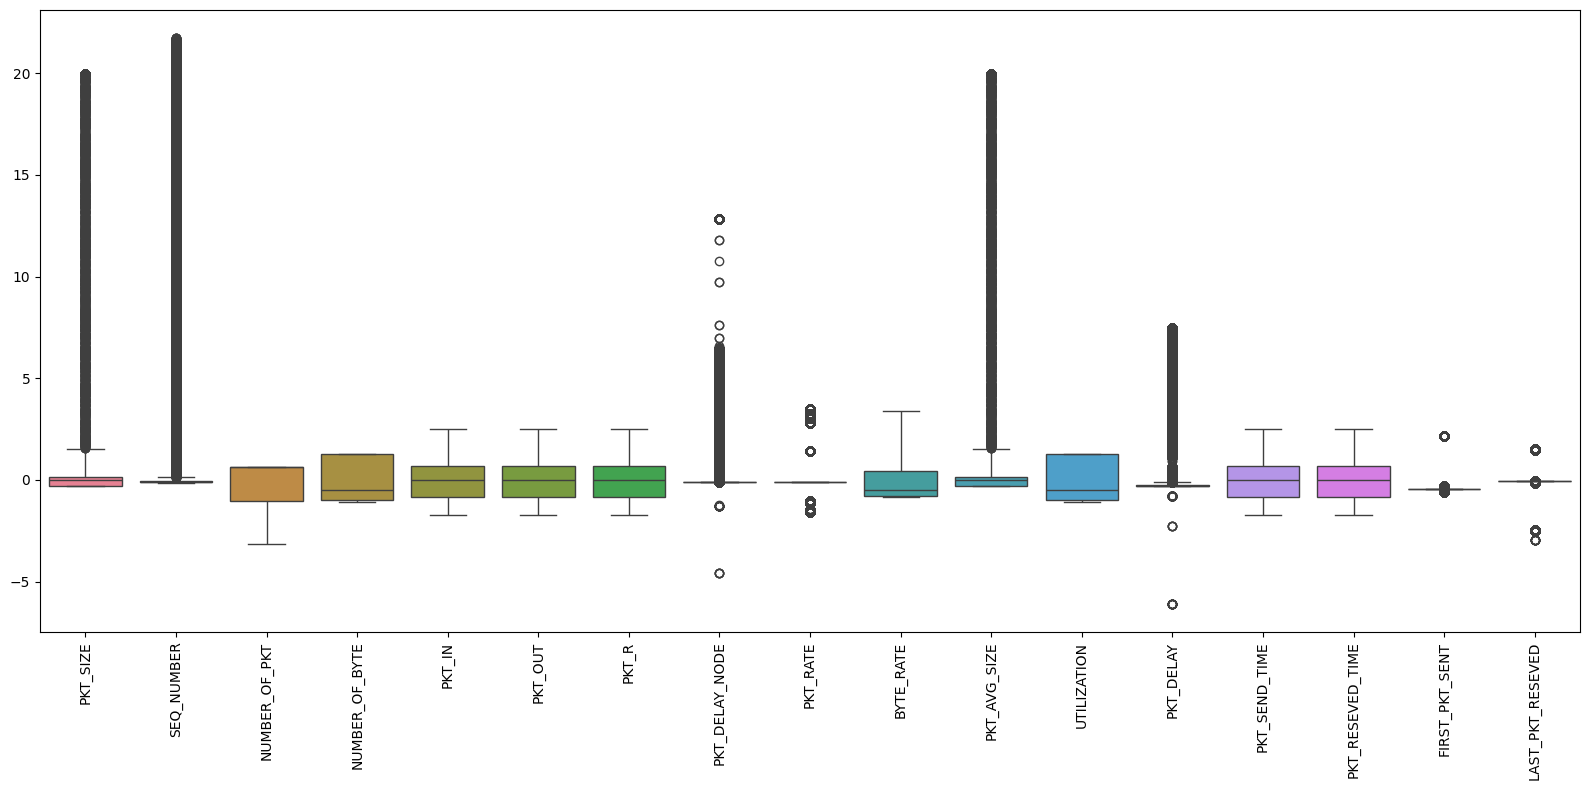

In [40]:
plt.figure(figsize=(16,8))
sns.boxplot( data = df_X_scaled, whis= 3.0 )
plt.xticks(rotation=90)
plt.tight_layout()

The box plots show that same features hava some outliners but those outliners could be normal when the network is under attack since some of the malicious attacks are direct to overflows the network either with many requests or by requesting very large packages to overload the system. Therefore, I am not delete those outliners since that could be vital to classify some of the malicious attacks.

### 2.3.4 PCA Scatter Plot

In [41]:
pca2d = PCA(n_components=2)

pc = pca2d.fit_transform(df_scaled.iloc[:,:-1].values)

In [42]:
pca2d.explained_variance_ratio_

array([0.34825085, 0.21457388])

In [43]:
pc_df = pd.DataFrame(data = pc , columns = ['PC1', 'PC2'])
pc_df['target'] = df_target
pc_df.target.value_counts()

,count
target,
Normal,310441
UDP-Flood,32138
Smurf,2069
SIDDOS,1069
HTTP-FLOOD,648


In [44]:
pc_df['target_binary'] = df_target
pc_df['target_binary'] = pc_df['target_binary'].replace(to_replace=['Normal', 'UDP-Flood', 'Smurf', 'SIDDOS', 'HTTP-FLOOD'], value=['Normal', 'Malicious','Malicious','Malicious','Malicious'])
pc_df.target_binary.value_counts()

,count
target_binary,
Normal,310441
Malicious,35924


I plot two PCA scatter plots, one with the orginal number of different types of malicious flows and one where I have merged all them in one attack.

In [45]:
#plt.figure(figsize=(12, 12))
#plt.subplot(2, 2, 1)
#sns.scatterplot(
#    data=pc_df, x="PC1", y="PC2", hue="target", alpha = 0.4)

#plt.title('PCA Scatter Plot')

#plt.subplot(2, 2, 2)
#sns.scatterplot(
#    data=pc_df, x="PC1", y="PC2", hue="target_binary", alpha = 0.4)

#plt.title('PCA Scatter Plot binary')
#plt.show()

Even after merging the malicious attacks in only one type of attacks, the points are not linearly separable as in the case in which the types of attacks are kept separated, since same of the points belonging to a class are overlapped by other points belonging to another class that I make visiable by adding a alpha value in the plots.

## 2.4 check for highly correlated features

### Correlation

I check for correlation between the features and drop the ones that are highly correlated with other features since those could reduce the perfomance of the claissifier. I select only the numeric features to calculate the correlation without including the first two columns <font color=red>SRC_ADD</font> and <font color=red>DES_ADD</font> since they correspond only to the source and destination of the packeges sent.  

In [46]:
#select only the numeric features
df_corr = df_X[df_X.columns[2:]].select_dtypes(include=['float64','int64'])

In [47]:
df_corr.shape

(864268, 17)

Only 17 out 28 feartures are numeric ones.

#### Plot Seaborn Heatmap

I plot the correlation heatmap from seaborn to check if between the features there are some of them highly correlated.

peak memory: 3700.43 MiB, increment: 112.17 MiB


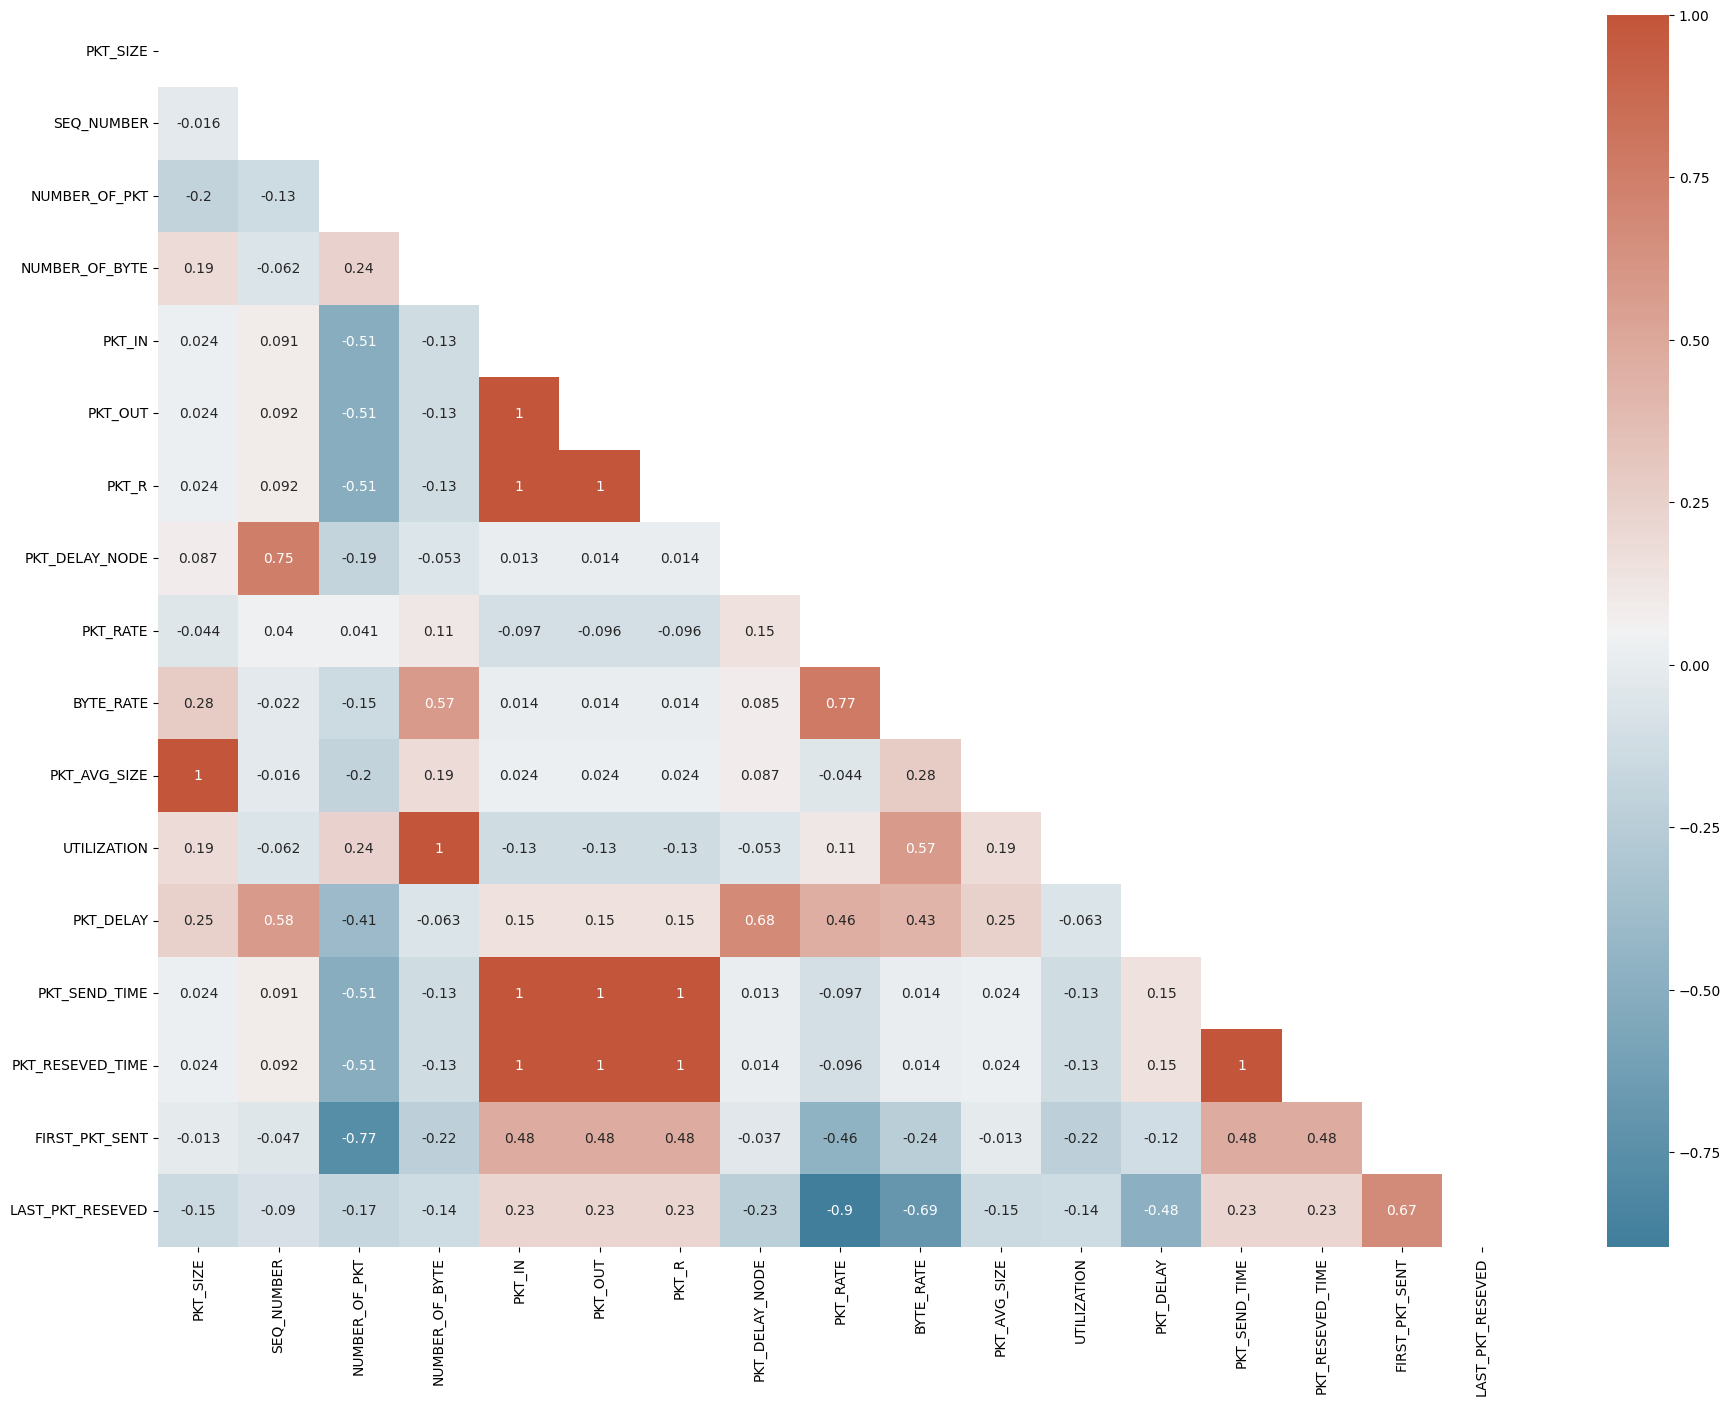

In [48]:
%%memit
fig, ax = plt.subplots(figsize=(22, 16))
corr = df_corr.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

## 2.4.1 Drop highly correlated features

Select and drop the columns that have a correlation above __0.95__.

In [49]:
correlation_matrix = df_corr.corr().abs()
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool))


to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(); print(to_drop)


['PKT_OUT', 'PKT_R', 'PKT_AVG_SIZE', 'UTILIZATION', 'PKT_SEND_TIME', 'PKT_RESEVED_TIME']


__6 columns are above the threshold:__<br>
<font color=red>PKT_OUT,<br> PKT_R,<br> PKT_AVG_SIZE,<br> UTILIZATION,<br> PKT_SEND_TIME,<br> PKT_RESEVED_TIME</font>.

I drop those features from the original dataset.

I drop also the first two columns <font color=red>SRC_ADD</font> and <font color=red>DES_ADD</font> that are category columns that do not add any important information on the attack flows since they just are the names of the sources and destinations of the request packages.

In [50]:
#I have excluded the first two columns SRC_ADD and DES_ADD
df_clean =df_X[df_X.columns[2:]].drop(to_drop, axis = 1)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864268 entries, 1896118 to 682597
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   PKT_ID            864268 non-null  object 
 1   FROM_NODE         864268 non-null  object 
 2   TO_NODE           864268 non-null  object 
 3   PKT_TYPE          864268 non-null  object 
 4   PKT_SIZE          864268 non-null  int64  
 5   FID               864268 non-null  object 
 6   SEQ_NUMBER        864268 non-null  int64  
 7   NUMBER_OF_PKT     864268 non-null  int64  
 8   NUMBER_OF_BYTE    864268 non-null  int64  
 9   NODE_NAME_FROM    864268 non-null  object 
 10  NODE_NAME_TO      864268 non-null  object 
 11  PKT_IN            864268 non-null  float64
 12  PKT_DELAY_NODE    864268 non-null  float64
 13  PKT_RATE          864268 non-null  float64
 14  BYTE_RATE         864268 non-null  float64
 15  PKT_DELAY         864268 non-null  float64
 16  FIRST_PKT_SENT    8

In [51]:
df_num = df_clean.select_dtypes(include=['float64','int64'])
#df_target = df_clean[df_clean.columns[-1]]

__I concatenate the features not scaled with the new dummy features FLAGS and the target variable that I will use to train the binary classifier.__

In [52]:
df_reduced = pd.concat([df_num, df_X.iloc[:,-2:], df_target], axis=1)

In [53]:
df_reduced.head(2)

,PKT_SIZE,SEQ_NUMBER,NUMBER_OF_PKT,NUMBER_OF_BYTE,PKT_IN,PKT_DELAY_NODE,PKT_RATE,BYTE_RATE,PKT_DELAY,FIRST_PKT_SENT,LAST_PKT_RESEVED,FLAGS_0,FLAGS_1,PKT_CLASS
1896118,55,4821,16103,885665,15.777890,0.0,328.432001,18063.800000,0.000000,1.030038,50.059974,True,False,Normal
1959586,64,-1,210,13440,9.118647,0.0,23.255775,1488.369621,0.030015,0.108642,9.138657,True,False,Normal


# 3. Balance the dataset

## 3.1 Check if the data is unbalanced

### I create a table with frequencies for each class and their percentage over the total types of Network Logs

In [54]:
keys_classes = df_reduced.PKT_CLASS.value_counts().keys()
value_classes = []
percentage_classes = []

for i in range(len(df_reduced.PKT_CLASS.value_counts())):
    value_classes.append(df_reduced.PKT_CLASS.value_counts()[i])
    percentage_classes.append(round(df_reduced.PKT_CLASS.value_counts(normalize=True)[i]*100, 2))
res = {keys_classes[i]: value_classes[i] for i in range(len(keys_classes))}

df_count = pd.DataFrame.from_dict(res, orient ='index', columns = ['Frequency'])
df_count['Percentage'] = percentage_classes
(df_count.style.background_gradient(subset=['Frequency', 'Percentage'], cmap='cividis')
 .format({'Frequency': '{}', 'Percentage': '{}%'}))


,Frequency,Percentage
Normal,774384,89.6%
UDP-Flood,80538,9.32%
Smurf,5036,0.58%
SIDDOS,2666,0.31%
HTTP-FLOOD,1644,0.19%


### The dataset is extremely unbalanced as expected since most of the time the network is not under attack.

## 3.2 Merge Malicious Flows in one category

#### Binary labels
I merge all the malicious network flows in only one attack.
To Normal Network flows, I assign 0 and 1 for Malicious Network flows.

In [55]:
df_reduced['PKT_CLASS'] = df_reduced['PKT_CLASS'].replace(to_replace=['Normal', 'UDP-Flood', 'Smurf', 'SIDDOS', 'HTTP-FLOOD'], value=[0, 1, 1,1,1])

I split the target feature from the other features.

In [56]:
df_target = df_reduced[df_reduced.columns[-1]]

In [57]:
df_X_reduced = df_reduced.iloc[:,:-1]

In [58]:
df_X_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 864268 entries, 1896118 to 682597
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   PKT_SIZE          864268 non-null  int64  
 1   SEQ_NUMBER        864268 non-null  int64  
 2   NUMBER_OF_PKT     864268 non-null  int64  
 3   NUMBER_OF_BYTE    864268 non-null  int64  
 4   PKT_IN            864268 non-null  float64
 5   PKT_DELAY_NODE    864268 non-null  float64
 6   PKT_RATE          864268 non-null  float64
 7   BYTE_RATE         864268 non-null  float64
 8   PKT_DELAY         864268 non-null  float64
 9   FIRST_PKT_SENT    864268 non-null  float64
 10  LAST_PKT_RESEVED  864268 non-null  float64
 11  FLAGS_0           864268 non-null  bool   
 12  FLAGS_1           864268 non-null  bool   
dtypes: bool(2), float64(7), int64(4)
memory usage: 113.0 MB


## 3.3 Split the dataset in two sets

I split that dataset in two sets, one for training and the other one for testing. The size of test dataset is the 33% of the whole dataset. I am not stratifying the data since there is no need to do it. There are only two clasess and the minority class is very numerous.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(df_X_reduced, df_target,
                                                    test_size=0.33, random_state=42)

In [60]:
print(f'Number of Normal flows {y_train.value_counts()[0]} and number attacks {y_train.value_counts()[1]} of the Training dataset')

Number of Normal flows 518790 and number attacks 60269 of the Training dataset


In [61]:
print(f'Number of Normal flows {y_test.value_counts()[0]} and number attacks {y_test.value_counts()[1]} of the Test dataset')

Number of Normal flows 255594 and number attacks 29615 of the Test dataset


## 3.4 SMOTE technique to balance the train dataset

To balance the dataset I have employed a technique that oversamples the minority class called __Synthetic Minority Oversampling Technique__ (SMOTE) (Chawla, Bowyer, Hall, & Kegelmeyer, 2002). The figures  below depict how this technique works. From figure on the left hand side, This technique locates the data points of the minority class and draws new synthetic examples ‘along the line segments joining any/all of the k minority class nearest neighbours’.

In [62]:
from IPython.display import display, HTML,IFrame
IFrame(src="https://www.thepythoncode.com/media/articles/handling-imbalance-data-imblearn-smote-variants-python/smote.png", width=700, height=100)

#### Over-sampling to balance training dataset

In [63]:
balance = SMOTE()
print('Before Resampling dataset shape %s' % Counter(y_train))
X_train_bal, y_train_bal = balance.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_train_bal))

Before Resampling dataset shape Counter({0: 518790, 1: 60269})
Resampled dataset shape Counter({1: 518790, 0: 518790})


## 3.5 Split the train dataset for validation use

For the test harness, I use oly <font color=blue>10%</font> of the training data as validation dataset and the same set of data points is used to tune the hyperparameters.

In [64]:
X_val_bal_sample, X_train_bal, y_val_bal_sample, y_train_bal = train_test_split(X_train_bal, y_train_bal,
                                                    test_size=0.90, random_state=42)

In [65]:
X_val_bal_sample.shape

(103758, 13)

# 4. Test Harness with Cross Validation

I have selected three learning algorthms, namely Logistic regression, Decison Tre and eXtreme Gradient Boosting (XGBoost) algorithms.
I use a pipeline of each learning algorithm chosen in which I have tested the perfomance of those algorithms when using either scaled or not scaled datapoints. As a scaler, I use the StandardScaler.

In [66]:
def test_harness(models,X_train,y_train, splits):

    """
        A test harness used to spot check the best model using different metrics
            Accuracy
            Fi_score
            Recall
            Precision
        It runs 4 - the number metrics - times the number of the split for each model and save
        the mean value of each metric score.
        Parmeters:
            models = list of pipelines with different classifiers
            X_train and y_train = respectively pandas dataframe for the features and target series
            splits = num of Kfold
        Return:
           db_results = dataframe of the mean results for each metric scores for each classifier
           results = the score values for each iteraction
    """
    #for the parameters scoring
    scoring_acc = metrics.make_scorer(metrics.accuracy_score)
    scoring_prec = metrics.make_scorer(metrics.precision_score)
    scoring_rec = metrics.make_scorer(metrics.recall_score)
    scoring_f1 = metrics.make_scorer(metrics.f1_score)

    score_list = []
    score_list.append(scoring_acc)
    score_list.append(scoring_prec)
    score_list.append(scoring_rec)
    score_list.append(scoring_f1)

    names_score = ['acc', 'prec', 'rec', 'f1']
    name_score_model = []

    #to store results of cv in a data set
    results_std = []
    results_mean = []
    results = []
    time_models =[]

    for name, model in models:
        for score, name_score in zip(score_list, names_score):
            kfold = KFold(n_splits=splits)

            #timing the model
            start = time.time()
            #cross validation
            results_cv = cross_val_score(model, X_train, y_train, cv=kfold, scoring= score)
            end = time.time()

            #save the results metrics
            results_mean.append(round(results_cv.mean(),5))
            results_std.append(round(results_cv.std(),5))
            results.append(results_cv)
            time_models.append(round(end - start, 5))
            name_score_model.append((name, name_score))
            print('model :', name, '-' ' time :',str(round(end - start, 5)))

    name_dict_db_results = [' '.join(map(str,name_score_model[i])) for i in range(len(name_score_model))]
    dictionary_results = {'Model': name_dict_db_results, 'Mean': results_mean, 'Std': results_std, 'time_models' :time_models }
    db_results = pd.DataFrame(dictionary_results)

    return db_results, results
#Adapted from - Brownlee, J. (2016) Machine learning mastery with Python: understand your data, create accurate models, and work projects end-to-end.

## 4.1 Pipelines of learning algorithms

__I set the pipelines with and without scaling the datapoints.__
I choose three leanring algorithms:
<br>`Logistic Regression`
<br>`Decision Tree`
<br>`RandomForest`

In [67]:
#pipelines of the models with different vectorization methods
logi_model = Pipeline([('LOGI', LogisticRegression(random_state = 0, n_jobs=-1))])
logi_model_sc = Pipeline([('scale', StandardScaler()),('LOGI', LogisticRegression(random_state = 0, n_jobs=-1))])
DCT_model =  Pipeline([('DCT',DecisionTreeClassifier(random_state=0))])
DCT_model_sc =  Pipeline([('scale', StandardScaler()),('DCT',DecisionTreeClassifier(random_state=0))])
RFC_model = Pipeline([('RFC', RandomForestClassifier(n_jobs=-1))])
RFC_model_sc = Pipeline([('scale', StandardScaler()),('RFC', RandomForestClassifier(n_jobs=-1))])

models = []
models.append(('LOGI', logi_model))
models.append(('LOGI_SC', logi_model_sc))
models.append(('DCT', DCT_model))
models.append(('DCT_SC', DCT_model_sc))
models.append(('RFC', RFC_model))
models.append(('RFC_SC', RFC_model_sc))

In [68]:
db_results, results = test_harness(models, X_val_bal_sample, y_val_bal_sample, 5)

model : LOGI - time : 12.23904
model : LOGI - time : 10.25493
model : LOGI - time : 9.47953
model : LOGI - time : 10.29798
model : LOGI_SC - time : 7.90826
model : LOGI_SC - time : 9.15387
model : LOGI_SC - time : 9.14539
model : LOGI_SC - time : 7.49884
model : DCT - time : 4.49142
model : DCT - time : 4.30442
model : DCT - time : 3.2744
model : DCT - time : 3.29059
model : DCT_SC - time : 4.14273
model : DCT_SC - time : 5.14637
model : DCT_SC - time : 3.56733
model : DCT_SC - time : 3.57768
model : RFC - time : 61.76731
model : RFC - time : 58.26949
model : RFC - time : 58.79957
model : RFC - time : 62.48378
model : RFC_SC - time : 58.16797
model : RFC_SC - time : 56.27573
model : RFC_SC - time : 56.03152
model : RFC_SC - time : 56.01972


In [69]:
db_results

,Model,Mean,Std,time_models
0,LOGI acc,0.91892,0.00198,12.23904
1,LOGI prec,0.99778,0.00044,10.25493
2,LOGI rec,0.83985,0.00362,9.47953
3,LOGI f1,0.91203,0.00214,10.29798
4,LOGI_SC acc,0.93377,0.00117,7.90826
5,LOGI_SC prec,0.99530,0.00112,9.15387
6,LOGI_SC rec,0.87178,0.00262,9.14539
7,LOGI_SC f1,0.92945,0.00121,7.49884
8,DCT acc,0.95802,0.00108,4.49142
9,DCT prec,0.95973,0.00138,4.30442


## 4.2 Spot-check the best model using Box and Whiskers Plots

I split the different results by the learning algorithm so I can plot the results in a single plot for each of those algorithms.

In [70]:
values = pd.DataFrame()
ls_log = [0,1,2,3,4,5,6,7]
ls_dc = [8,9,10,11,12,13,14,15]
ls_rf = [16,17,18,19,20,21,22,23]

res_log = []
res_dc=[]
res_rf=[]
for i in range(24):
    if i in ls_log:
        da = results[i]
        res_log.append(da)
    if i in ls_rf:
        da = results[i]
        res_rf.append(da)
    if i in ls_dc:
        da = results[i]
        res_dc.append(da)

### Boxplots of the different learning algorithms of the test harness
The boxplot helps to spot check and select the best algorithm based by its performance and the variance of its perfomance over the different folds.

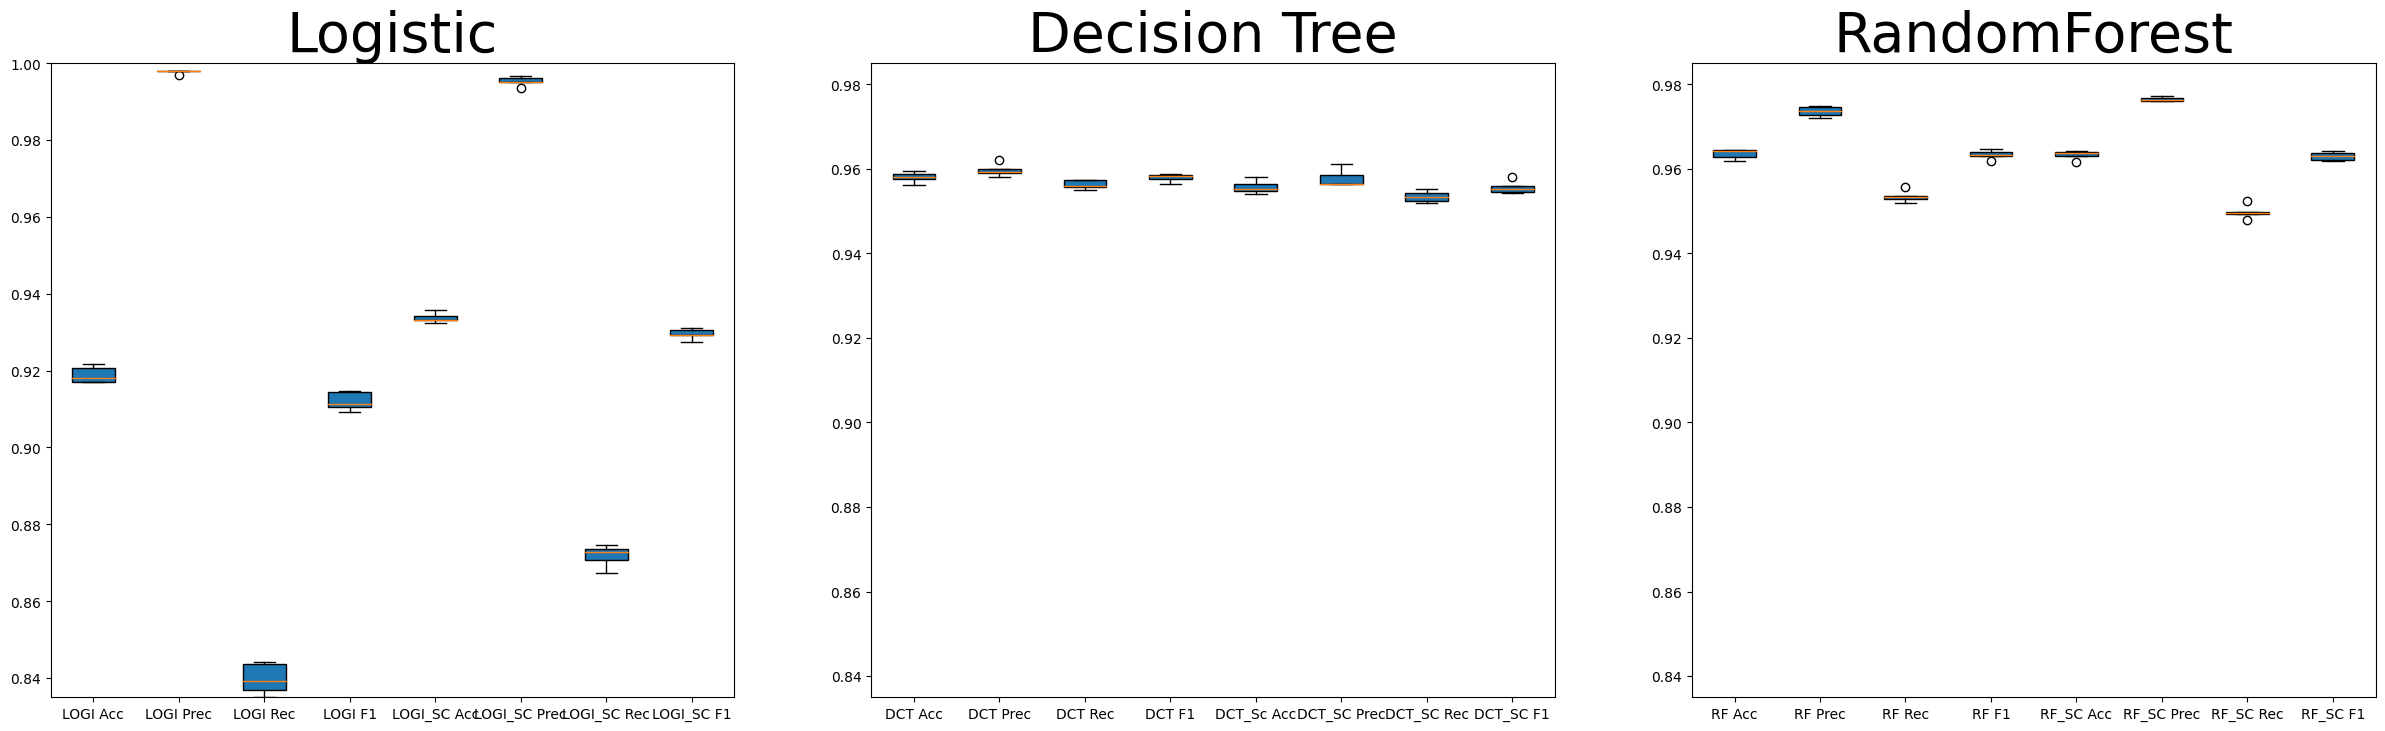

In [71]:
plt.figure(figsize=(30,28))

plt.subplot(3, 3, 1)
plt.title("Logistic",fontsize=40)
plt.ylim(0.835, 1)
plt.boxplot(res_log,patch_artist=True,
                  labels=['LOGI Acc','LOGI Prec','LOGI Rec' ,'LOGI F1', 'LOGI_SC Acc','LOGI_SC Prec','LOGI_SC Rec' ,'LOGI_SC F1'])

plt.subplot(3, 3, 2)
plt.title("Decision Tree",fontsize=40)
plt.ylim(0.835,0.985)
plt.boxplot(res_dc,patch_artist=True,
                  labels=['DCT Acc','DCT Prec', 'DCT Rec', 'DCT F1','DCT_Sc Acc','DCT_SC Prec', 'DCT_SC Rec', 'DCT_SC F1'])

plt.subplot(3, 3, 3)
plt.title("RandomForest",fontsize=40)
plt.ylim(0.835, 0.985)
plt.boxplot(res_rf,patch_artist=True,
                  labels=['RF Acc','RF Prec', 'RF Rec', 'RF F1','RF_SC Acc','RF_SC Prec', 'RF_SC Rec', 'RF_SC F1'])
plt.show()

Decision Tree has a more stable performance than the other two algorithm but RandomForest with data not scaled has slightly a better performance with a higher F1-Score and Precision scores than the Decision Tree model. Therefore, I opt to train the binary classifier using the RandomForest algorithm with unscaled data. The training would be conducted using a larger datasest - only 10% of training data was used for the test hareness - that would help the RandomForest algorithm to outperform a simple Decision Tree algorithm.
N.B. The Logistic plot has a different maximum set for the y-axis.

# 5. Training phase

## 5.1 Train the best learning algorithm

__The function below returns the evaluation metrics for a binary classification.__

In [72]:
def calc_binary_class_metrics(targets, model, name_model, data_type):


    """The function returns the evaluation metrics for a binary
    classification - Class 1.

    Parameters
    ----------
    targets : target variable
    model : model fit and trained that needs to be evaluated
    name_model : string name of the learning algorithm
    data_type : string name of the type of data used to eveluate the model - test or validation

    Returns
    -------
    a dataset with all the metrics stored in one row

    """
    # Metrics
    precision = metrics.precision_score(targets, model)
    recall = metrics.recall_score(targets, model)
    f1_score = metrics.f1_score(targets, model)
    balanced_accuracy = metrics.balanced_accuracy_score(targets, model)
    accuracy = metrics.accuracy_score(targets, model)

    #to calculate AUC for multiclass
    auc = metrics.roc_auc_score(targets, model)

    #calculate specificity
    m_c = metrics.confusion_matrix(targets, model)
    tn = m_c[0, 0]
    tp = m_c[1, 1]
    fn = m_c[1, 0]
    fp =m_c[0, 1]
    #https://scikit-learn.org/stable/modules/model_evaluation.html
    specificity = tn / (tn + fp)

    #creates the dictionar to be saved in the results_score data frame
    scores = {
         'Model': [name_model],
        'Data' : [data_type],
         'Precision': [precision],
         'Recall': [recall],
        'Specificity' : [specificity],
        'F1-score' : [f1_score],
        'Accuracy': [accuracy],
        'Bal Accuracy' : [balanced_accuracy],
        'AUC' : [auc]
    }

    scores = pd.DataFrame(scores)

    return scores

__Initialisation dataset to store all the results.__

In [73]:
results_score = pd.DataFrame()

### 5.1.1 Traing without tuning the parameters

First, __I train the learning algorithm without tuning its hyperparamters.__

In [74]:
random.seed(2)
rf = RandomForestClassifier(random_state = 8, n_jobs = -1, max_depth = 80, n_estimators =500 )
rf.fit(X_train_bal, y_train_bal)
rf_pred = rf.predict(X_train)

print("Accuracy on train data: \n",metrics.accuracy_score(y_train, rf_pred))
print("Classification report: \n",metrics.classification_report(y_train, rf_pred))

Accuracy on train data: 
 0.9974544908204518
Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    518790
           1       0.99      0.99      0.99     60269

    accuracy                           1.00    579059
   macro avg       0.99      0.99      0.99    579059
weighted avg       1.00      1.00      1.00    579059



In [76]:
# sc = calc_binary_class_metrics(y_train, rf_pred, 'RF not tuned', 'Train')
# results_score = results_score.append(sc)
# results_score

import pandas as pd

# ... your existing code ...

sc = calc_binary_class_metrics(y_train, rf_pred, 'RF not tuned', 'Train')
results_score = pd.concat([results_score, sc], ignore_index=True) # Use pd.concat instead of append
results_score

,Model,Data,Precision,Recall,Specificity,F1-score,Accuracy,Bal Accuracy,AUC
0,RF not tuned,Train,0.988826,0.986693,0.998705,0.987758,0.997454,0.992699,0.992699


In [77]:
rf_test_pred = rf.predict(X_test)

print("Accuracy on test data: \n",metrics.accuracy_score(y_test, rf_test_pred))
print("Classification report: \n",metrics.classification_report(y_test, rf_test_pred))
print('Confusion Matrix test: \n' + str(metrics.confusion_matrix(y_test, rf_test_pred)))

Accuracy on test data: 
 0.976154328930714
Classification report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    255594
           1       0.89      0.87      0.88     29615

    accuracy                           0.98    285209
   macro avg       0.94      0.93      0.94    285209
weighted avg       0.98      0.98      0.98    285209

Confusion Matrix test: 
[[252508   3086]
 [  3715  25900]]


In [79]:
# sc = calc_binary_class_metrics(y_test, rf_test_pred, 'RF not tuned', 'Test')
# results_score = results_score.append(sc)
# results_score

# sc = calc_binary_class_metrics(y_test, rf_test_pred, 'RF not tuned', 'Test')
# results_score = results_score.append(sc) # This line is causing the error
# results_score

import pandas as pd

sc = calc_binary_class_metrics(y_test, rf_test_pred, 'RF not tuned', 'Test')
results_score = pd.concat([results_score, sc], ignore_index=True) # Use pd.concat instead of append
results_score

,Model,Data,Precision,Recall,Specificity,F1-score,Accuracy,Bal Accuracy,AUC
0,RF not tuned,Train,0.988826,0.986693,0.998705,0.987758,0.997454,0.992699,0.992699
1,RF not tuned,Test,0.893535,0.874557,0.987926,0.883944,0.976154,0.931241,0.931241


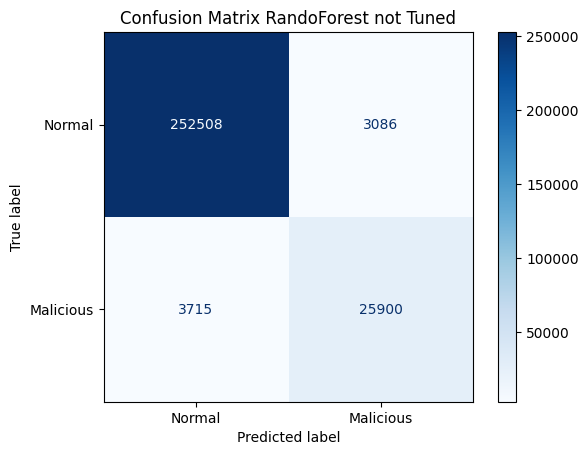

In [81]:
# plot_conf = metrics.plot_confusion_matrix(rf, X_test, y_test, values_format = 'n',
#                                    cmap=plt.cm.Blues, display_labels = ['Normal' , 'Malicious'] )
# title = 'Confusion Matrix RandoForest not Tuned'
# plot_conf.ax_.set_title(title)
# plt.show()




!pip install scikit-learn --upgrade

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sklearn


# ... your existing code ...

# Assuming 'rf', 'X_test', and 'y_test' are defined

# Calculate the confusion matrix
cm = confusion_matrix(y_test, rf.predict(X_test))

# Create the ConfusionMatrixDisplay object
plot_conf = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Malicious'])

# Plot the confusion matrix
plot_conf.plot(cmap=plt.cm.Blues, values_format='n')

# Set the title
title = 'Confusion Matrix RandoForest not Tuned'
plot_conf.ax_.set_title(title)

# Display the plot
plt.show()

This is a clear case of overfitting of the training data since the metric scores acchieved on the train data are, in some of them 10 percent higher that ones acchieved by the model on the test data. Now, I can try to improve those reults by tuning the hyperparameters to see if the classifier will be able to classify correctly more network flows.

## 5.2 Tune the hyperparameters of the learning algorithm

to tune the hyperparameters, I use the validation dataset used for the test harness

### 5.2.1 Random Search CV to find the best hyperparameters

__Hyperparamters Grid__

In [82]:
param_grid = {'min_samples_leaf': [1, 2, 4],
              'min_samples_split' : [2, 5, 10],
             'max_features' : ['auto', 'sqrt'],
              'max_depth': [20, 40, 80, 100, None],
              'n_estimators' : [200, 600, 800],
             'bootstrap' : [True, False]}

I choose for to tune the hyperparameters RandomizedSearchCV in which not all parameter values are tried out, but rather a fixed number of parameter settings which is given by n_iter that I set to 75 with a number of cross validation folds of 3 which means that there are 225 fits.

In [83]:
rand_for = RandomForestClassifier(random_state=8)

random_search = RandomizedSearchCV(estimator=rand_for,
                                   param_distributions=param_grid,
                                   n_iter=25,
                                   scoring='accuracy',
                                   cv=3,
                                   verbose=1)

random_search.fit(X_val_bal_sample, y_val_bal_sample)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=8),
                   n_iter=25,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [20, 40, 80, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 600, 800]},
                   scoring='accuracy', verbose=1)

In [84]:
random_search.best_estimator_

RandomForestClassifier(bootstrap=False, max_depth=40, min_samples_leaf=4,
                       min_samples_split=10, n_estimators=800, random_state=8)

In [ ]:
bes_par_rf = random_search.best_estimator_

I save the parameters found in a variable

In [ ]:
#bes_par_rf = RandomForestClassifier(bootstrap=False,max_depth=80, min_samples_leaf=4,
#                       min_samples_split=10, n_estimators=600, random_state=8)

RandomForest trained with the hyperparameters tuned.

## 5.3 Traing with the tuned the parameters

__I train the model using the train dataset.__

In [86]:
# random.seed(2)
# rf_tuned = bes_par_rf
# rf_tuned.fit(X_train_bal, y_train_bal)
# rf_tuned_pred_train = rf_tuned.predict(X_train)

# print("Accuracy on train data: \n",metrics.accuracy_score(y_train, rf_tuned_pred_train))
# print("Classification report: \n",metrics.classification_report(y_train, rf_tuned_pred_train))
# print('Confusion Matrix train: \n' + str(metrics.confusion_matrix(y_train, rf_tuned_pred_train)))


import random
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics


random.seed(2)

# Define bes_par_rf here, uncommenting the line from the previous cell:
bes_par_rf = RandomForestClassifier(bootstrap=False, max_depth=80, min_samples_leaf=4,
                      min_samples_split=10, n_estimators=600, random_state=8)

rf_tuned = bes_par_rf
rf_tuned.fit(X_train_bal, y_train_bal)
rf_tuned_pred_train = rf_tuned.predict(X_train)

print("Accuracy on train data: \n", metrics.accuracy_score(y_train, rf_tuned_pred_train))
print("Classification report: \n", metrics.classification_report(y_train, rf_tuned_pred_train))
print('Confusion Matrix train: \n' + str(metrics.confusion_matrix(y_train, rf_tuned_pred_train)))

Accuracy on train data: 
 0.9869978706832983
Classification report: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    518790
           1       0.99      0.88      0.93     60269

    accuracy                           0.99    579059
   macro avg       0.99      0.94      0.96    579059
weighted avg       0.99      0.99      0.99    579059

Confusion Matrix train: 
[[518310    480]
 [  7049  53220]]


In [88]:
# sc = calc_binary_class_metrics(y_train, rf_tuned_pred_train, 'RF tuned', 'Training')
# results_score = results_score.append(sc)
# results_score

import pandas as pd

sc = calc_binary_class_metrics(y_train, rf_tuned_pred_train, 'RF tuned', 'Training')
results_score = pd.concat([results_score, sc], ignore_index=True)
results_score

,Model,Data,Precision,Recall,Specificity,F1-score,Accuracy,Bal Accuracy,AUC
0,RF not tuned,Train,0.988826,0.986693,0.998705,0.987758,0.997454,0.992699,0.992699
1,RF not tuned,Test,0.893535,0.874557,0.987926,0.883944,0.976154,0.931241,0.931241
2,RF tuned,Training,0.991061,0.883041,0.999075,0.933938,0.986998,0.941058,0.941058


__Test the model using the test dataset.__

In [89]:
rf_tuned_pred = rf_tuned.predict(X_test)

print("Accuracy on test data: \n",metrics.accuracy_score(y_test, rf_tuned_pred))
print("Classification report: \n",metrics.classification_report(y_test, rf_tuned_pred))
print('Confusion Matrix test: \n' + str(metrics.confusion_matrix(y_test, rf_tuned_pred)))

Accuracy on test data: 
 0.9841554789645488
Classification report: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    255594
           1       0.97      0.87      0.92     29615

    accuracy                           0.98    285209
   macro avg       0.98      0.94      0.96    285209
weighted avg       0.98      0.98      0.98    285209

Confusion Matrix test: 
[[254813    781]
 [  3738  25877]]


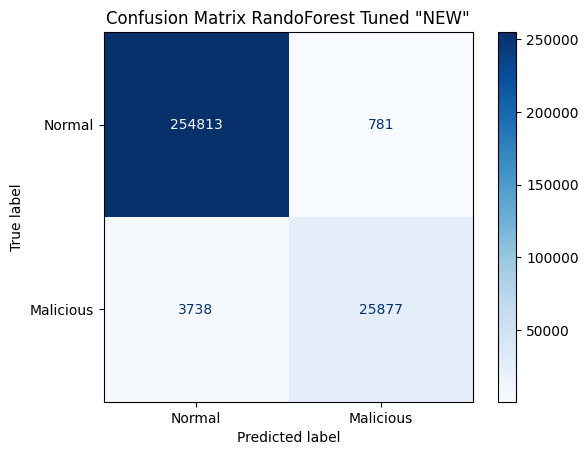

In [91]:
# plot_conf = metrics.plot_confusion_matrix(rf_tuned, X_test, y_test, values_format = 'n',
#                                    cmap=plt.cm.Blues, display_labels = ['Normal' , 'Malicious'] )
# title = 'Confusion Matrix RandoForest Tuned "NEW"'
# plot_conf.ax_.set_title(title)

# plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ... (your existing code) ...

# Generate the confusion matrix
cm = confusion_matrix(y_test, rf_tuned_pred)

# Create the ConfusionMatrixDisplay object
plot_conf = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Malicious'])

# Plot the confusion matrix
plot_conf.plot(cmap=plt.cm.Blues, values_format='n')

# Set the title
title = 'Confusion Matrix RandoForest Tuned "NEW"'
plot_conf.ax_.set_title(title)

plt.show()

In [93]:
# sc = calc_binary_class_metrics(y_test, rf_tuned_pred, 'RF tuned', 'Test')
# results_score = results_score.append(sc)
# results_score

# sc = calc_binary_class_metrics(y_test, rf_tuned_pred, 'RF tuned', 'Test')
# results_score = results_score.append(sc) # This line is causing the error
# results_score

# Replace the problematic line with pd.concat:
sc = calc_binary_class_metrics(y_test, rf_tuned_pred, 'RF tuned', 'Test')
results_score = pd.concat([results_score, sc], ignore_index=True)
results_score

,Model,Data,Precision,Recall,Specificity,F1-score,Accuracy,Bal Accuracy,AUC
0,RF not tuned,Train,0.988826,0.986693,0.998705,0.987758,0.997454,0.992699,0.992699
1,RF not tuned,Test,0.893535,0.874557,0.987926,0.883944,0.976154,0.931241,0.931241
2,RF tuned,Training,0.991061,0.883041,0.999075,0.933938,0.986998,0.941058,0.941058
3,RF tuned,Test,0.970703,0.873780,0.996944,0.919695,0.984155,0.935362,0.935362


It is worth nothing that the perfomance on training data has decreased after the tuning but the results on the test dataset show that the model is not overfitting the training data anymore since now, after the tuning, those results are very similar to the ones obtained on the train dataset.

# 6. XAI

## 6.1 SHAP

Shap is an explainable AI framework derived from the shapley values of the game theory. It shows the contribution or the importance of each feature on the prediction of the model. It offers global and local interpretability of the predictions.  

In [94]:
shap_values_tree = shap.TreeExplainer(rf_tuned).shap_values(X_test[0:20])

### 6.1.1 SHAP Global Explaination

__Shap Summary plot__
The bar plot function creates a global feature importance plot which is used to give a global explaination of the  model. It retuns the mean absolute value for each feature over all the given samples.

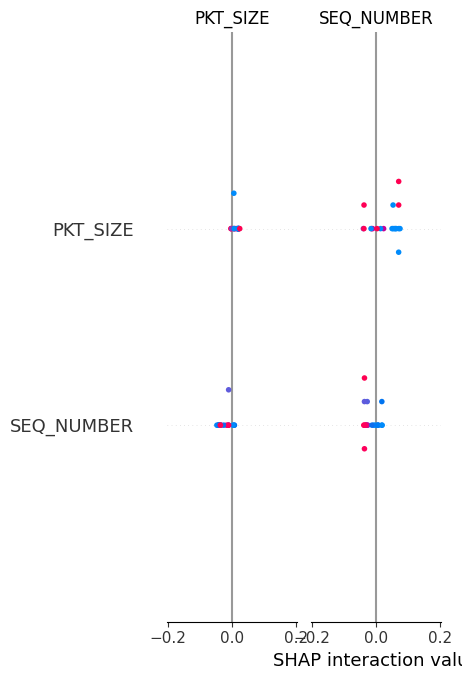

In [95]:
shap.summary_plot(shap_values_tree, X_test[0:20])

The most important feature is `LAST_PKT_RESEVED` and second most important is `PKT_DELAY`.

In [96]:
shap_values_tree[0].shape

(13, 2)

In [97]:
shap_interaction_values_tree = shap.TreeExplainer(rf_tuned).shap_interaction_values(X_test.iloc[0:20])

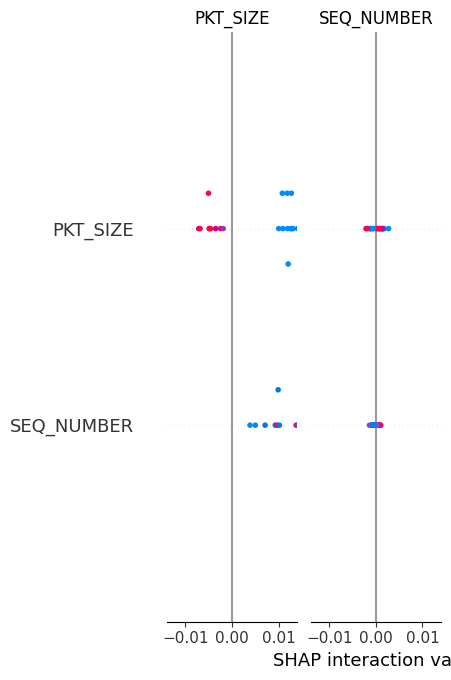

In [99]:
# shap.summary_plot(shap_interaction_values_tree[1],
#                  X_test.iloc[0:20])

import shap

# Assuming rf_tuned is your trained RandomForest model
shap_interaction_values_tree = shap.TreeExplainer(rf_tuned).shap_interaction_values(X_test.iloc[0:20])

# Choose a specific feature index for visualization (e.g., 0 for the first feature)
feature_index = 0

# Plot the SHAP interaction values for the selected feature
# Note: We use shap_interaction_values_tree[:, feature_index, :, class_index] to get the desired values
# shap_interaction_values_tree has shape (samples, features, features, classes) for main effects and interactions
# We are extracting:
# - All samples using :
# - A specific feature at index feature_index using feature_index
# - All interaction or main effects using :
# - All class effects using :

#If your model is binary classification you don't need class_index
shap.summary_plot(shap_interaction_values_tree[:, feature_index, :, :], X_test.iloc[0:20])

Feature importance: Variables are ranked in descending order.
Impact: The horizontal location shows whether the effect of that value is associated with a higher or lower prediction.
Correlation: A high values of  LAST_PKT_RESEVED has a high impact on the likelihood that a flow is a malicious ones.

In [109]:
shap.initjs()
# Get the expected value for the desired class (e.g., class 0)
expected_value = shap.TreeExplainer(rf_tuned).expected_value[0]

# Select the SHAP values for the first instance (index 0) and the desired class (class 0 if binary classification)
shap_values = shap_values_tree[0][:, 0] # Select all features and the first class

# Select the first instance from X_test
X_test_instance = X_test.iloc[[0]]  # Use iloc[[0]] to select the first row as a DataFrame


#Generate the force plot
shap.force_plot(expected_value, shap_values, X_test_instance)

### 6.1.2 SHAP Local Explaination

In [110]:
print(X_test.iloc[11])

PKT_SIZE                   1500
SEQ_NUMBER                 2461
NUMBER_OF_PKT              9108
NUMBER_OF_BYTE         13662000
PKT_IN                60.977143
PKT_DELAY_NODE          0.00012
PKT_RATE            1016.522962
BYTE_RATE             1524780.0
PKT_DELAY              0.033461
FIRST_PKT_SENT              1.0
LAST_PKT_RESEVED       9.959955
FLAGS_0                    True
FLAGS_1                   False
Name: 2151068, dtype: object


In [111]:
features = list(df_reduced.columns)

In [112]:
rf_tuned.predict(X_test.values[10].reshape(1, -1))

array([1])

In [113]:
y_test[10]

1

In [117]:
# shap.initjs()
# # Use the full feature list instead of excluding the last feature
# shap.force_plot(shap.TreeExplainer(rf_tuned).expected_value[0], shap_values_tree[0][10,:], features)


shap.initjs()
# Use the full feature list instead of excluding the last feature
# Get the number of features from the shape of shap_values_tree
num_features = shap_values_tree[0].shape[1]

# Ensure 'features' has the same length as the number of shap values
shap.force_plot(shap.TreeExplainer(rf_tuned).expected_value[0],
                shap_values_tree[0][10,:],
                features[:num_features]) # Slice features to match the length of shap_values

In [121]:
# shap.initjs()
# shap.force_plot(shap.TreeExplainer(rf_tuned).expected_value[0], shap_values_tree[1][10,:], features[:-1])


shap.initjs()
# Use the full feature list instead of excluding the last feature

# Get the number of features from the shape of shap_values_tree
num_features = shap_values_tree[1].shape[1]  # Get the number of features from shap_values_tree

# Ensure 'features' has the same length as the number of shap values
shap.force_plot(shap.TreeExplainer(rf_tuned).expected_value[1],  # Use expected_value for the second class (index 1)
                shap_values_tree[1][10,:],
                features[:num_features])  # Slice features to match the length of shap_values

## 6.2 LIME

Lime creates a small set of perturbed data starting from the input. Then, it explains the input by using an interpretable model (i.e., decision trees).

### 6.2.1 LIME Local Explaination

In [122]:
features = list(df_reduced.columns)

In [123]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names = features[:-1])

In [124]:
exp = explainer.explain_instance(X_test.values[10],rf_tuned.predict_proba, top_labels=1)

In [125]:
exp.show_in_notebook(show_table=True, show_all=False)

In [126]:
exp = explainer.explain_instance(X_test.values[1], rf_tuned.predict_proba, top_labels=0)
exp.show_in_notebook(show_table=True, show_all=False)